In [1]:
from langgraph.graph import StateGraph,START,MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [2]:
load_dotenv()

True

In [3]:
model = ChatGroq(model="openai/gpt-oss-20b")

In [4]:
MAX_TOKENS = 150

In [5]:
def call_model(state: MessagesState):

    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [6]:
builder = StateGraph(MessagesState)
builder.add_node("call_model",call_model)
builder.add_edge(START,"call_model")

In [7]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

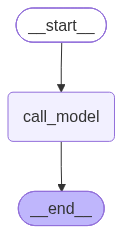

In [8]:
graph


In [9]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Anjali."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Anjali.


'Hello Anjali! 👋 How can I help you today?'

In [10]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 36
Hi, my name is Anjali.
Hello Anjali! 👋 How can I help you today?
I am learning LangGraph.


'Nice to meet you, Anjali! 👋  \nLangGraph is a powerful framework for building **large‑language‑model (LLM) powered workflows**—think of it as a “state‑machine” for LLMs that lets you:\n\n* **Chain multiple LLM calls** (or other tools) together\n* **Maintain conversational context** across turns\n* **Handle branching logic** (e.g., if a user asks about weather vs. stock prices)\n* **Persist state** so you can pause, resume, or audit a flow\n* **Integrate external APIs** (weather, databases, etc.) as nodes\n\nBelow is a quick‑start guide to get you rolling, followed by some resources and a mini‑project idea.\n\n---\n\n## 1. Install the SDK\n\n```bash\npip install langgraph\n# If you want the official OpenAI wrapper:\npip install openai\n```\n\n> **Tip** – If you’re on a Mac/Windows/Linux with conda, create a fresh environment first:  \n> `conda create -n langgraph python=3.11`  \n> `conda activate langgraph`\n\n---\n\n## 2. Basic Concepts\n\n| Concept | What it is | Why it matters |\n|-

In [12]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 13
Can you explain short term memory?


'**Short‑Term Memory (STM) – The “mental scratch‑pad”**\n\nShort‑term memory is the cognitive system that holds a small amount of information in an active, easily retrievable state for a brief period (typically seconds to a minute). Think of it as a mental *scratch‑pad* or *buffer* that lets you keep a few items in mind while you’re working on a task.\n\n---\n\n### 1. Core Features\n\n| Feature | What it means |\n|---------|---------------|\n| **Capacity** | Roughly 7\u202f±\u202f2 “chunks” of information (Miller, 1956). In modern work‑memory models the effective limit is closer to 4 chunks. |\n| **Duration** | Without rehearsal, items decay after ~20–30\u202fseconds. With rehearsal (repeating or mentally manipulating), you can keep information longer. |\n| **Encoding** | Usually verbal (phonological loop) or visual‑spatial (visuospatial sketchpad). |\n| **Retrieval** | Items can be recalled or used to guide behavior. |\n\n---\n\n### 2. How It Works (Baddeley’s Working‑Memory Model)\n\

In [13]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Anjali.
------------------------------------------------------------------------------------------------------------------------
Hello Anjali! 👋 How can I help you today?
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
Nice to meet you, Anjali! 👋  
LangGraph is a powerful framework for building **large‑language‑model (LLM) powered workflows**—think of it as a “state‑machine” for LLMs that lets you:

* **Chain multiple LLM calls** (or other tools) together
* **Maintain conversational context** across turns
* **Handle branching logic** (e.g., if a user asks about weather vs. stock prices)
* **Persist state** so you can pause, resume, or audit a flow
* **Integrate external APIs** (weather, databases, etc.) as nodes

Below is a quick‑start guide to get you rol